In [1]:
# ============================================================
# Real-World ANN Example: Handwritten Digit Recognition
# Dataset: MNIST | Framework: TensorFlow / Keras
# ============================================================

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [3]:
# ─────────────────────────────────────────
# 1. LOAD & EXPLORE DATA
# ─────────────────────────────────────────

In [4]:
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [5]:
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Image shape      : {X_train.shape[1:]}")   # (28, 28)
print(f"Classes          : {np.unique(y_train)}")   # 0–9

Training samples : 60000
Test samples     : 10000
Image shape      : (28, 28)
Classes          : [0 1 2 3 4 5 6 7 8 9]


In [6]:
# ─────────────────────────────────────────
# 2. PREPROCESS
# ─────────────────────────────────────────

In [7]:
# Flatten 28×28 → 784 and normalize pixels to [0, 1]

In [8]:
X_train = X_train.reshape(-1, 784).astype("float32") / 255.0
X_test  = X_test.reshape(-1, 784).astype("float32") / 255.0

In [9]:
# One-hot encode labels  (e.g. 3 → [0,0,0,1,0,0,0,0,0,0])
y_train_ohe = keras.utils.to_categorical(y_train, num_classes=10)
y_test_ohe  = keras.utils.to_categorical(y_test,  num_classes=10)

In [10]:
# ─────────────────────────────────────────
# 3. BUILD THE ANN MODEL
# ─────────────────────────────────────────
#  Architecture:
#    Input  → 784 neurons
#    Hidden → 512 (ReLU) + Dropout(0.3)
#    Hidden → 256 (ReLU) + Dropout(0.3)
#    Hidden → 128 (ReLU)
#    Output → 10  (Softmax)

In [11]:
model = keras.Sequential([
    layers.Input(shape=(784,)),

    # Hidden Layer 1
    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Hidden Layer 2
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Hidden Layer 3
    layers.Dense(128, activation="relu"),

    # Output Layer - 10 classes
    layers.Dense(10, activation="softmax"),
    ], name = "ANN_MNIST")

In [12]:
model.summary()

Model: "ANN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,506 (2.18 MB)

 Trainable params: 568,970 (2.17 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [13]:
# ─────────────────────────────────────────
# 4. COMPILE
# ─────────────────────────────────────────

In [14]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss=keras.losses.CategoricalCrossentropy(),metrics=["accuracy",])

In [15]:
# ─────────────────────────────────────────
# 5. CALLBACKS
# ─────────────────────────────────────────

In [16]:
callbacks = [
    # Stop early if val_loss stops improving
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),

    # Reduce LR when plateau detected
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
]

In [17]:
# ─────────────────────────────────────────
# 6. TRAIN
# ─────────────────────────────────────────

In [18]:
print("\nTraining Model.....")
history = model.fit(
    X_train, y_train_ohe,
    epochs=30,
    batch_size=128,
    validation_split=0.1,  # 10% of training data used for validation
    callbacks=callbacks,
    verbose=1
)


Training Model.....
Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8506 - loss: 0.4800 - val_accuracy: 0.9743 - val_loss: 0.0842 - learning_rate: 0.0010
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9575 - loss: 0.1367 - val_accuracy: 0.9788 - val_loss: 0.0760 - learning_rate: 0.0010
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9687 - loss: 0.0982 - val_accuracy: 0.9797 - val_loss: 0.0742 - learning_rate: 0.0010
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9738 - loss: 0.0830 - val_accuracy: 0.9793 - val_loss: 0.0685 - learning_rate: 0.0010
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9768 - loss: 0.0714 - val_accuracy: 0.9808 - val_loss: 0.0675 - learning_rate: 0.0010
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9785 - loss: 0.0674 - val_accuracy: 0.9818 - val_loss: 0.0669 - learning_rate: 0.0010
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accur

In [19]:
# ─────────────────────────────────────────
# 7. EVALUATE
# ─────────────────────────────────────────

In [20]:
test_loss, test_acc = model.evaluate(X_test, y_test_ohe,verbose=1)
print(f"\n Test Accuracy : {test_acc * 100:.2f}%")
print(f"\n Test Loss : {test_loss * 100:.4f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9825 - loss: 0.0597

 Test Accuracy : 98.53%

 Test Loss : 4.7460%


In [21]:
# ─────────────────────────────────────────
# 8. VISUALISE TRAINING CURVES
# ─────────────────────────────────────────

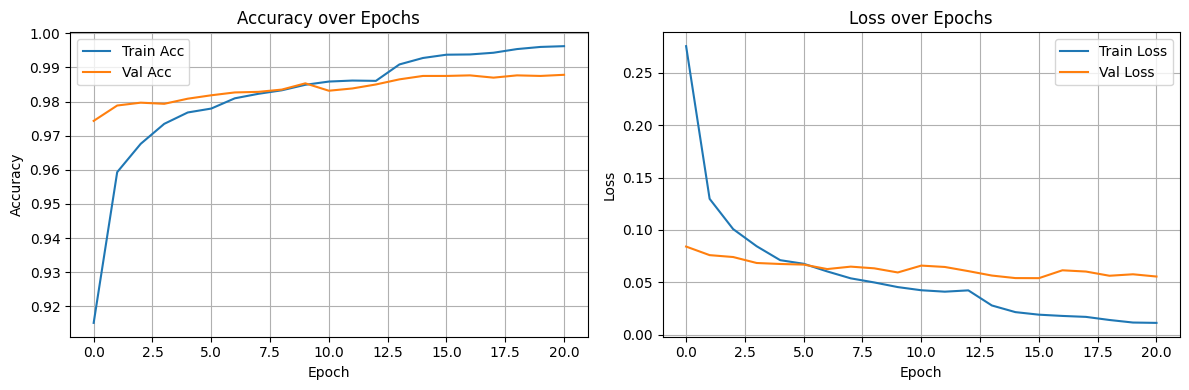

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"],     label="Train Acc")
axes[0].plot(history.history["val_accuracy"], label="Val Acc")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

In [23]:
# ─────────────────────────────────────────
# 9. PREDICT ON SAMPLE IMAGES
# ─────────────────────────────────────────

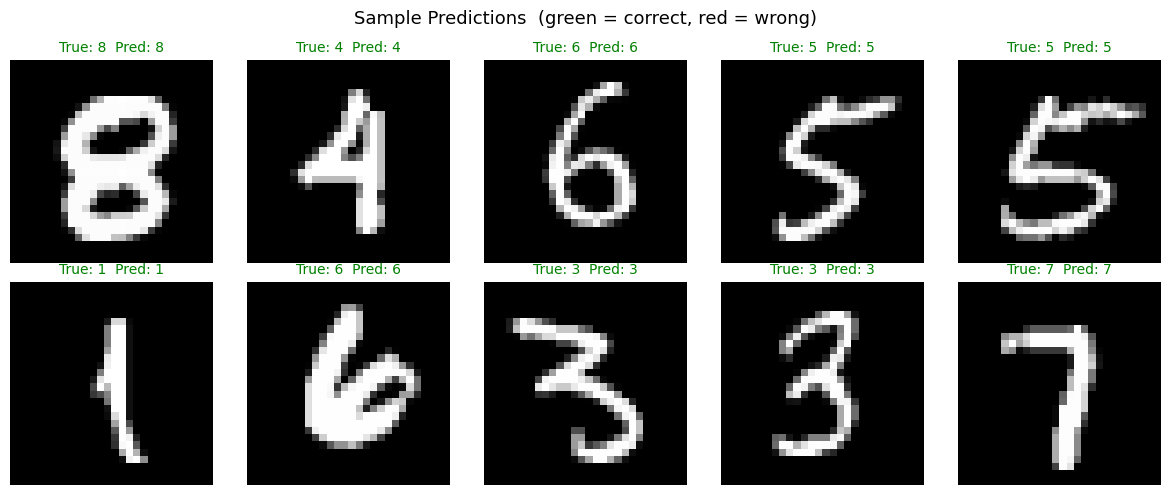

In [24]:
num_smaples = 10
indices = np.random.choice(len(X_test), size=num_smaples, replace=False)
samples = X_test[indices]
true_labels = y_test[indices]

prediction = model.predict(samples, verbose=0)
predicted_labels = np.argmax(prediction, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i].reshape(28, 28), cmap="gray")
    color = "green" if predicted_labels[i] == true_labels[i] else "red"
    ax.set_title(
        f"True: {true_labels[i]}  Pred: {predicted_labels[i]}",
        color=color, fontsize=10
    )
    ax.axis("off")

plt.suptitle("Sample Predictions  (green = correct, red = wrong)", fontsize=13)
plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150)
plt.show()


In [25]:
# ─────────────────────────────────────────
# 10. SAVE THE MODEL
# ─────────────────────────────────────────
model.save("ann_mnist_model.keras")
print("\nModel saved as ann_mnist_model.keras")



Model saved as ann_mnist_model.keras


In [26]:
# ─────────────────────────────────────────
# 11. RELOAD & RE-USE (inference example)
# ─────────────────────────────────────────

In [27]:
loaded_model = keras.models.load_model("ann_mnist_model.keras")

single_image  = X_test[0:1]                          # shape (1, 784)
single_pred   = loaded_model.predict(single_image, verbose=0)
print(f"\nLoaded model — single prediction: {np.argmax(single_pred)}  "
      f"(true label: {y_test[0]})")


Loaded model — single prediction: 7  (true label: 7)
